In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
# 4.2
exoplanets = pd.read_csv("exoplanet_data.csv", comment="#")
print(f"The shape of the data is {exoplanets.shape}.")
print(f"This means there are {exoplanets.shape[0]} rows and {exoplanets.shape[1]} columns.")
print(list(exoplanets.columns))
print("I have no idea what sy_pnum, pl_rade, pl_radeerr1, pl_insollim, and st_logg mean.")

The shape of the data is (564, 92).
This means there are 564 rows and 92 columns.
['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim'

In [32]:
# 4.3
# planet name - pl_name - Planet name most commonly used in the literature - most used name of the planet
# host name - hostname - Stellar name most commonly used in the literature - name of star associated with planet
# discovery method - discoverymethod - Method by which the planet was first identified - how planet was discovered
# spectral type - st_spectype - Classification of the star based on their spectral characteristics following the Morgan-Keenan system - spectral 
#   classification of star associated with planet
# equilibrium temperature - pl_eqt - The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly 
#     imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body - the temperature
#     a planet would be if it was at thermodynamic equilibrium (blackbody), theoretically
# planet mass or mass*sini (Jupiter) - pl_bmassj - Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), 
#     depending on availability, and measured in Jupiter masses - most accurate estimation of planetary mass measured in Jupiter masses
exoplanets_reduced = exoplanets[["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]]
exoplanets_filtered = exoplanets_reduced.dropna()
exoplanets_filtered

print(f"The shape of the dataset is {exoplanets_filtered.shape}.")
print(f"There are {exoplanets_filtered.shape[0]} rows and {exoplanets_filtered.shape[1]} columns.")
print(exoplanets_filtered.head(5))
print(exoplanets_filtered.tail(5))
print(list(exoplanets_filtered.columns))

The shape of the dataset is (67, 6).
There are 67 rows and 6 columns.
    pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
2  DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3  DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4  DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
5  DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
6  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
542   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
544   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
550   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
553       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
563  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'p

In [38]:
# 4.4
print(exoplanets_filtered.value_counts("discoverymethod"))
# the methods of discovery are transit, radial velocity, and imaging.
# 52 planets discovered by transit (most common), 13 planets discovered by radial velocity, 2 planets discovered by imaging (least common).
# transit: planet is detected by dip in brightness of star
# radial velocity: planet is detected by gravitational effects on star's path
# imaging: planet is directly seen 

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64


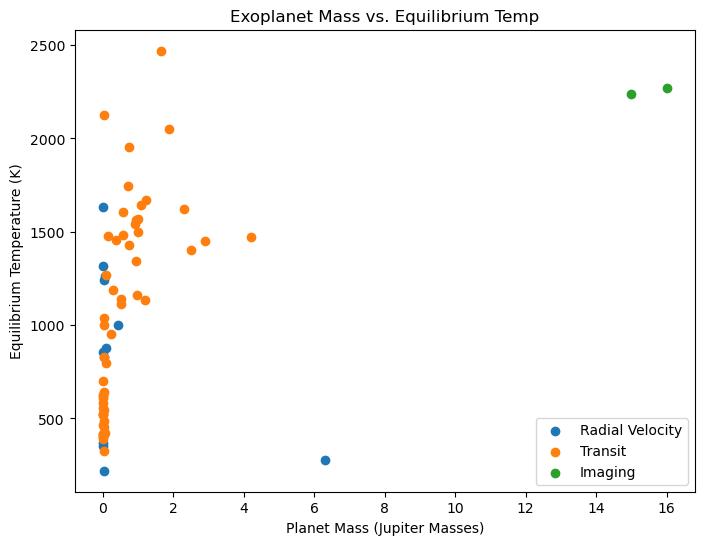

In [54]:
plt.figure(figsize=(8,6))

for discoverymethod in exoplanets_filtered["discoverymethod"].unique():
    subset = exoplanets_filtered[exoplanets_filtered["discoverymethod"] == discoverymethod]
    plt.scatter(subset["pl_bmassj"], subset["pl_eqt"], label=discoverymethod)

plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.title("Exoplanet Mass vs. Equilibrium Temp")
plt.legend()

plt.show()

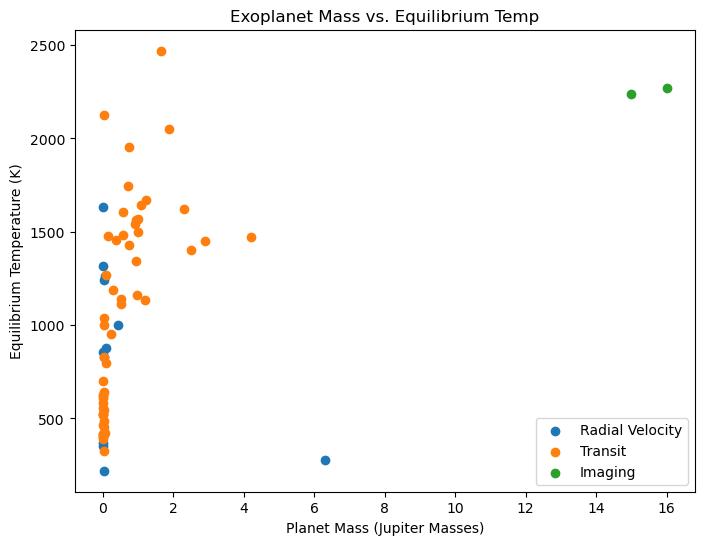

In [69]:
plt.figure(figsize=(8,6))

for discoverymethod in exoplanets_filtered["discoverymethod"].unique():
    subset = exoplanets_filtered[exoplanets_filtered["discoverymethod"] == discoverymethod]
    plt.scatter(subset["pl_bmassj"], subset["pl_eqt"], label=discoverymethod)

plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.title("Exoplanet Mass vs. Equilibrium Temp")
plt.legend()

plt.show()

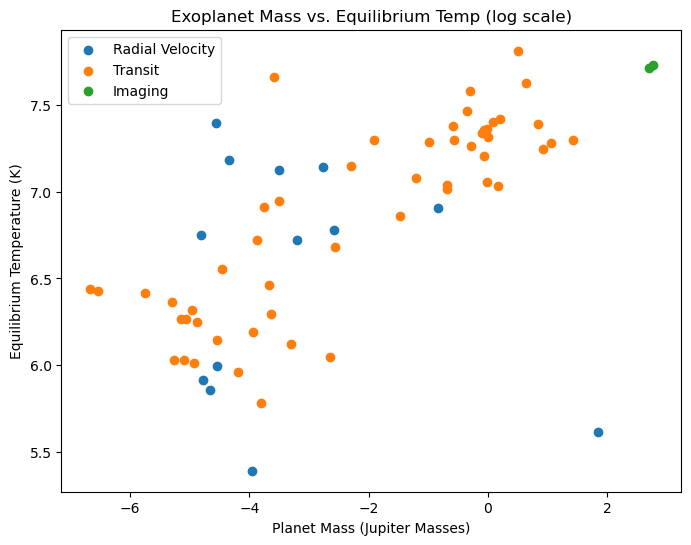

In [57]:
plt.figure(figsize=(8,6))

for discoverymethod in exoplanets_filtered["discoverymethod"].unique():
    subset = exoplanets_filtered[exoplanets_filtered["discoverymethod"] == discoverymethod]
    plt.scatter(np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label=discoverymethod)

plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.title("Exoplanet Mass vs. Equilibrium Temp (log scale)")
plt.legend()

plt.show()

In [86]:
# exoplanets found by imaging are more likely to be massive
massive_exoplanets = exoplanets[exoplanets["pl_bmassj"] > 5]
coldest_most_massive = massive_exoplanets.loc[massive_exoplanets["pl_eqt"].idxmin()]
print(coldest_most_massive)
planet_name = coldest_most_massive["pl_name"]
index = coldest_most_massive.pl_name  # DataFrame index
temp = coldest_most_massive["pl_eqt"]
mass = coldest_most_massive["pl_bmassj"]
star_type = coldest_most_massive["st_spectype"]
print(f"Name: {planet_name}")
print(f"Index: {index}")
print(f"Equilibrium Temperature: {temp} K")
print(f"Mass: {mass} Jupiter Masses")
print(f"Host Star Spectral Type: {star_type}")

pl_name           eps Ind A b
hostname            eps Ind A
default_flag                1
sy_snum                     3
sy_pnum                     1
                     ...     
sy_gaiamagerr1       0.007374
sy_gaiamagerr2      -0.007374
rowupdate          2024-08-07
pl_pubdate            2024-09
releasedate        2024-08-07
Name: 563, Length: 92, dtype: object
Name: eps Ind A b
Index: eps Ind A b
Equilibrium Temperature: 275.0 K
Mass: 6.31 Jupiter Masses
Host Star Spectral Type: K5 V


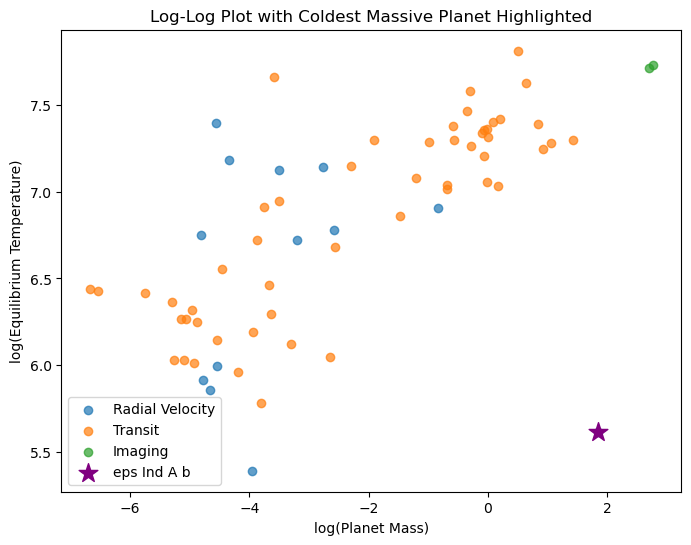

In [89]:
plt.figure(figsize=(8,6))

for method in exoplanets_filtered["discoverymethod"].unique():
    subset = exoplanets_filtered[exoplanets_filtered["discoverymethod"] == method]
    plt.scatter(np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label=method, alpha=0.7)

# Highlight the coldest massive planet
plt.scatter(np.log(coldest_most_massive["pl_bmassj"]),
            np.log(coldest_most_massive["pl_eqt"]),
            color='purple', s=200, marker='*', label=coldest_most_massive["pl_name"])

plt.title("Log-Log Plot with Coldest Massive Planet Highlighted")
plt.xlabel("log(Planet Mass)")
plt.ylabel("log(Equilibrium Temperature)")
plt.legend()
plt.show()

In [90]:
# What is the title of this paper?
#     "A temperate super-Jupiter imaged with JWST in the mid-infrared"
# Summarize the abstract to the best of your ability in your own words.
#     It reports the discovery of a new giant planet that is the largest in its system and is brighter than expected.
# Does your answer match the exoplanet?
#     Yes, the mass matches and so does the spectral type of the star and the temperature of the planet.
# What is special about the planet you found?
#     It's unusually bright and more metallic than expected for the size of the planet.
# Do the mass and equilibrium temperature match what the paper reported? If not, what are the differences?
#     Yes, they match!